# Test the betting strategies

### First we generate the data

In [7]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# import your class
# from your_module import ExponentialBet


# ----------------------------
# 1. DATA GENERATION
# ----------------------------

def generate_data(n=5000, d=5, rho=0.6, beta_strength=2.0, noise=1.0, seed=0):
    np.random.seed(seed)

    Sigma = rho * np.ones((d, d)) + (1 - rho) * np.eye(d)

    X = np.random.multivariate_normal(np.zeros(d), Sigma, size=n)

    j = 0

    beta = np.zeros(d)
    beta[j] = beta_strength

    gamma = np.ones(d)
    gamma[j] = 0.0

    eps = noise * np.random.randn(n)

    Y = X @ beta + X @ gamma + eps

    return X, Y, Sigma, j


# ----------------------------
# 2. EXACT CONDITIONAL SAMPLER
# ----------------------------

def sample_X_tilde(X_minus_j, j, Sigma, K=50):
    idx = np.arange(Sigma.shape[0]) != j

    Sigma11 = Sigma[j, j]
    Sigma12 = Sigma[j, idx]
    Sigma22 = Sigma[np.ix_(idx, idx)]

    Sigma22_inv = np.linalg.inv(Sigma22)

    mu = X_minus_j @ (Sigma12 @ Sigma22_inv).T
    var = Sigma11 - Sigma12 @ Sigma22_inv @ Sigma12.T

    noise = np.random.randn(len(X_minus_j), K) * np.sqrt(var)

    return mu[:, None] + noise


# ----------------------------
# 3. SETUP DATA
# ----------------------------

X, Y, Sigma, j = generate_data(beta_strength=0.8)

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.5, random_state=0
)


# ----------------------------
# 4. TRAIN LINEAR MODEL
# ----------------------------

model = LinearRegression()
model.fit(X_train, y_train)




LinearRegression()

In [8]:
from Sampler import GaussianSampler, DefaultSampler, RegressorSampler
samp_G = GaussianSampler(j=0)
samp_G.fit(X_train)
X_tilde_G = samp_G.sample(X_test)

samp_R = RegressorSampler(j=0)
samp_R.fit(X_train)
X_tilde_R = samp_R.sample(X_test)

samp_D = DefaultSampler(j=0)
samp_D.fit(X_train)
X_tilde_D = samp_D.sample(X_test)

In [9]:
X_tilde_D.shape

(2500,)

(array([ 13.,  61., 201., 513., 716., 599., 292.,  88.,  13.,   4.]),
 array([-3.32507596, -2.59721542, -1.86935488, -1.14149434, -0.4136338 ,
         0.31422674,  1.04208727,  1.76994781,  2.49780835,  3.22566889,
         3.95352943]),
 <BarContainer object of 10 artists>)

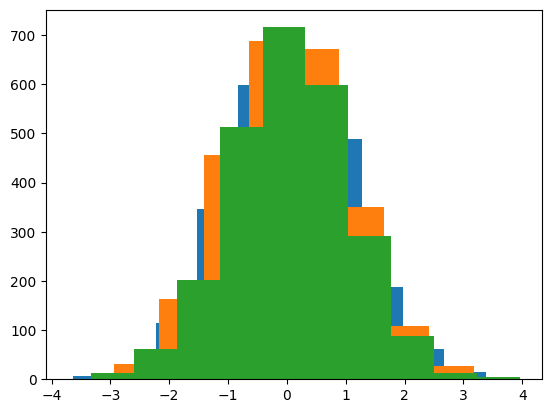

In [10]:
import matplotlib.pyplot as plt
plt.hist(X_tilde_G)
plt.hist(X_tilde_R)
plt.hist(X_tilde_D)



### Exponential strategy

Check under the alternative and then under the null

Final wealth vector: [1.80150148e+001 1.50474572e+068 3.49137701e+107 2.11597717e+125]
Mean wealth: [5.75198542e+000 5.26915571e+065 8.52219069e+104 4.70572390e+122]


(array([317., 117.,  31.,  17.,  10.,   3.,   0.,   2.,   1.,   1.]),
 array([ 0.03207325,  2.25261122,  4.47314918,  6.69368715,  8.91422511,
        11.13476307, 13.35530104, 15.575839  , 17.79637697, 20.01691493,
        22.2374529 ]),
 <BarContainer object of 10 artists>)

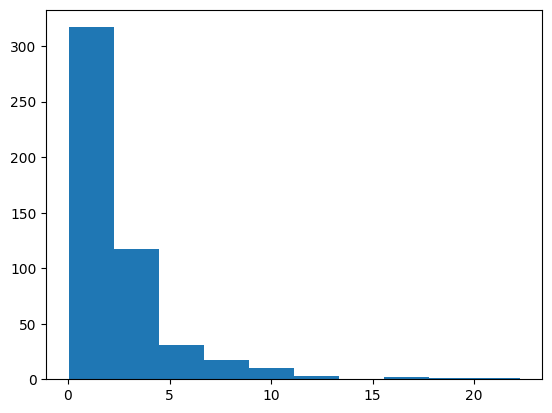

In [11]:
# ----------------------------
# 5. YOUR REAL STRATEGY
# ----------------------------
import numpy as np
from ExponentialBet import ExponentialBet  # adjust import
from utils import prepare_exponential_parameters

etas = prepare_exponential_parameters(0.01, 2, 4)
strategy = ExponentialBet(
    parameters=etas,
    exact=True
)


# ----------------------------
# 6. SEQUENTIAL LOOP
# ----------------------------

batch = 5
K = 50

n = len(X_test)

wealth_path = []
e_val_path_exp = []

for t in range(0, n - batch, batch):

    X_batch = X_test[t:t+batch]
    y_batch = y_test[t:t+batch]

    
    X_minus_j = np.delete(X_batch, j, axis=1)

    # conditional samples of X_j | X_-j
    X_tilde = sample_X_tilde(X_minus_j, j, Sigma, K=K)

    # YOUR REAL CALL
    e_val_exp = strategy.e_value(
        model=model,
        x=X_batch,
        x_j_tildes=X_tilde,
        y=y_batch,
        j=j
    )
    e_val_path_exp.append(e_val_exp)
    strategy.update()

    wealth_path.append(strategy.past_martingales.copy())


# ----------------------------
# 7. RESULTS
# ----------------------------

wealth_path = np.array(wealth_path)

print("Final wealth vector:", wealth_path[-1])
print("Mean wealth:", wealth_path.mean(axis=0))
plt.hist(e_val_path_exp)

### Coin-betting



Final wealth vector: [1.62677545e+01 1.22332666e+01 7.54011721e+00 4.91237516e+00
 3.56804988e+00 2.83652422e+00 2.40252371e+00 2.12499268e+00
 1.93570773e+00 1.79954503e+00 7.30888745e+13 3.24658842e+12
 1.46886126e+10 1.14763515e+08 2.96830061e+06 2.11596372e+05
 3.09488627e+04 7.42373427e+03 2.49804483e+03 1.06328219e+03
 2.58221380e+25 1.10395250e+23 7.11354915e+18 1.07115733e+15
 1.33320889e+12 1.02812865e+10 2.92469341e+08 2.05562632e+07
 2.69209821e+06 5.44178158e+05 1.00799078e+36 6.23147196e+32
 1.00633768e+27 4.39247283e+21 3.41998636e+17 3.36726381e+14
 2.07205848e+12 4.57691673e+10 2.44700457e+09 2.42966373e+08
 5.61755755e+45 7.12424267e+41 4.72873722e+34 8.55553211e+27
 5.25350715e+22 7.65590665e+18 1.12169447e+16 8.29990659e+13
 1.89290722e+12 9.52560988e+10 5.40326989e+54 1.91775881e+50
 8.17602742e+41 8.44189928e+33 5.03056411e+27 1.23964945e+23
 4.71832559e+19 1.24000456e+17 1.25632778e+15 3.29888275e+13
 1.02186972e+63 1.35288122e+58 5.63560790e+48 4.45002673e+39
 3.

(array([  3.,   7.,  17.,  19.,  29.,  32.,  37.,  81.,  83., 191.]),
 array([0.08 , 0.272, 0.464, 0.656, 0.848, 1.04 , 1.232, 1.424, 1.616,
        1.808, 2.   ]),
 <BarContainer object of 10 artists>)

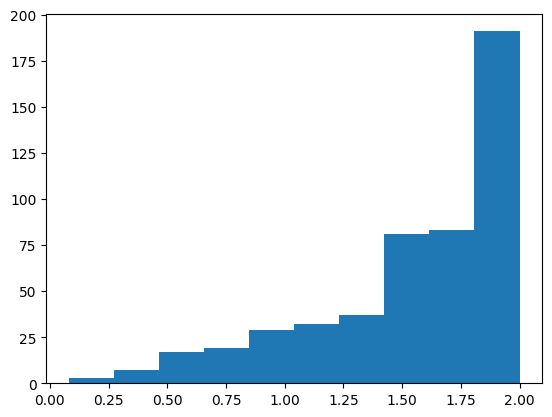

In [12]:
# ----------------------------
# 5. YOUR REAL STRATEGY
# ----------------------------
import numpy as np
from AntisymmetricBet import AntisymmetricBet  # adjust import
from utils import prepare_coin_betting_parameters, g_family_cb, update_g_func_static


params = prepare_coin_betting_parameters(lam_start = 0.01, lam_end = 1, lam_num = 10, M_start = 0.01, M_end = 5, M_num = 10)
strategy = AntisymmetricBet(
    g_family= g_family_cb, 
    update_g_func = update_g_func_static, 
    parameters=params,
)


# ----------------------------
# 6. SEQUENTIAL LOOP
# ----------------------------

batch = 5
K = 50

n = len(X_test)

wealth_path = []
e_val_path_cb = []
for t in range(0, n - batch, batch):

    X_batch = X_test[t:t+batch]
    y_batch = y_test[t:t+batch]

    
    X_minus_j = np.delete(X_batch, j, axis=1)

    # conditional samples of X_j | X_-j
    X_tilde = sample_X_tilde(X_minus_j, j, Sigma, K=K)

    # YOUR REAL CALL
    e_val_cb = strategy.e_value(
        model=model,
        x=X_batch,
        x_j_tildes=X_tilde,
        y=y_batch,
        j=j
    )
    e_val_path_cb.append(e_val_cb)
    strategy.update()

    wealth_path.append(strategy.past_martingales.copy())


# ----------------------------
# 7. RESULTS
# ----------------------------

wealth_path = np.array(wealth_path)

print("Final wealth vector:", wealth_path[-1])
print("Mean wealth:", wealth_path.mean(axis=0))
plt.hist(e_val_path_cb)

In [13]:
wealth_path.shape

(499, 100)

In [14]:
# ----------------------------
# 5. YOUR REAL STRATEGY
# ----------------------------
import numpy as np
from AntisymmetricBet import AntisymmetricBet  # adjust import
from utils import prepare_coin_betting_parameters, g_family_cb, update_g_func_static


params = prepare_coin_betting_parameters(lam_start = 0.01, lam_end = 1, lam_num = 10, M_start = 0.01, M_end = 5, M_num = 10)
strategy = AntisymmetricBet(
    g_family= g_family_cb, 
    update_g_func = update_g_func_static, 
    parameters=params,
)


# ----------------------------
# 6. SEQUENTIAL LOOP
# ----------------------------

batch = 5
K = 50

n = len(X_test)

wealth_path = []
e_val_path = []

for t in range(0, n - batch, batch):

    X_batch = X_test[t:t+batch]
    y_batch = y_test[t:t+batch]

    
    X_minus_j = np.delete(X_batch, j, axis=1)

    # conditional samples of X_j | X_-j
    X_tilde = sample_X_tilde(X_minus_j, j, Sigma, K=K)

    # YOUR REAL CALL
    e_val = strategy.e_value(
        model=model,
        x=X_batch,
        x_j_tildes=X_tilde,
        y=y_batch,
        j=j
    )

    e_val_path.append(e_val)
    
    strategy.update()

    wealth_path.append(strategy.past_martingales.copy())


# ----------------------------
# 7. RESULTS
# ----------------------------

wealth_path = np.array(wealth_path)

print("Final wealth vector:", wealth_path[-1])
print("Mean wealth:", wealth_path.mean(axis=0))

Final wealth vector: [1.59843789e+01 1.24314549e+01 7.61626087e+00 4.94097638e+00
 3.58601822e+00 2.85131771e+00 2.41495178e+00 2.13481059e+00
 1.94334053e+00 1.80575684e+00 6.00954967e+13 3.92235233e+12
 1.64970500e+10 1.22729530e+08 3.14516739e+06 2.24610304e+05
 3.28435223e+04 7.83070729e+03 2.61507140e+03 1.10693769e+03
 1.82434199e+25 1.57896417e+23 8.82150277e+18 1.21269729e+15
 1.48352982e+12 1.14743327e+10 3.26351306e+08 2.26936328e+07
 2.93157293e+06 5.86645501e+05 6.27060906e+35 1.05446959e+33
 1.37042379e+27 5.24426463e+21 3.98330609e+17 3.93667867e+14
 2.42275229e+12 5.27356821e+10 2.76597111e+09 2.70775811e+08
 3.14674037e+45 1.43076699e+42 7.04282359e+34 1.07344704e+28
 6.38618085e+22 9.34722142e+18 1.37024154e+16 9.95676915e+13
 2.21679451e+12 1.09579321e+11 2.78220326e+54 4.60818838e+50
 1.32851999e+42 1.10960865e+34 6.36633009e+27 1.57642726e+23
 6.00635390e+19 1.54543094e+17 1.52177309e+15 3.91184215e+13
 4.93377522e+62 3.95340895e+58 9.98955879e+48 6.11114297e+39
 4.

In [15]:
strategy.e_value(model=model,
        x=X_batch,
        x_j_tildes=X_tilde,
        y=y_batch,
        j=j)

np.float64(2.0)

(array([  7.,   3.,  18.,  18.,  26.,  46.,  45.,  64.,  83., 189.]),
 array([0.14083404, 0.32675063, 0.51266723, 0.69858383, 0.88450042,
        1.07041702, 1.25633361, 1.44225021, 1.62816681, 1.8140834 ,
        2.        ]),
 <BarContainer object of 10 artists>)

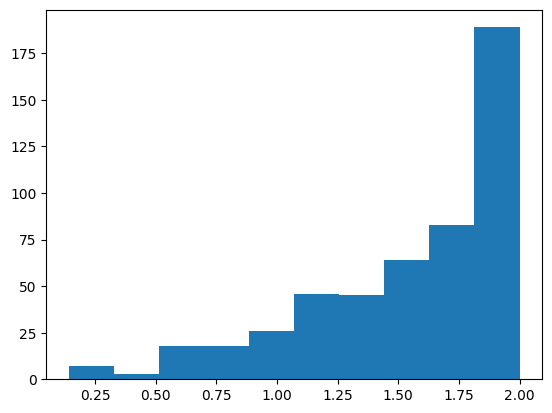

In [16]:
plt.hist(e_val_path)

### Test sign


In [17]:
# ----------------------------
# 5. YOUR REAL STRATEGY
# ----------------------------
import numpy as np
from AntisymmetricBet import AntisymmetricBet  # adjust import
from utils import prepare_lambda_parameters, g_family_sign, update_g_func_static

params_sign = prepare_lambda_parameters(lam_start = 0.01, lam_end = 1, lam_num = 5)
strategy_sign = AntisymmetricBet(
    g_family= g_family_sign, 
    update_g_func = update_g_func_static, 
    parameters=params_sign,
    prequential=False,
)


# ----------------------------
# 6. SEQUENTIAL LOOP
# ----------------------------

batch = 5
K = 50

n = len(X_test)

wealth_path = []
e_val_path_sign = []

for t in range(0, n - batch, batch):

    X_batch = X_test[t:t+batch]
    y_batch = y_test[t:t+batch]

    
    X_minus_j = np.delete(X_batch, j, axis=1)

    # conditional samples of X_j | X_-j
    X_tilde = sample_X_tilde(X_minus_j, j, Sigma, K=K)

    # YOUR REAL CALL
    e_val_sign = strategy_sign.e_value(
        model=model,
        x=X_batch,
        x_j_tildes=X_tilde,
        y=y_batch,
        j=j
    )

    strategy_sign.update()
    e_val_path_sign.append(e_val_sign)
    wealth_path.append(strategy_sign.past_martingales.copy())


# ----------------------------
# 7. RESULTS
# ----------------------------

wealth_path = np.array(wealth_path)

print("Final wealth vector:", wealth_path[-1])
print("Mean wealth:", wealth_path.mean(axis=0))

Final wealth vector: [1.61058316e+01 1.09618180e+28 1.32961911e+50 2.63260275e+68
 1.05246758e+83]
Mean wealth: [5.31363350e+00 1.41958997e+26 9.40071206e+47 1.36562017e+66
 4.52335077e+80]


(array([  6.,   8.,  13.,  18.,  33.,  31.,  42.,  62., 103., 183.]),
 array([0.5556 , 0.65054, 0.74548, 0.84042, 0.93536, 1.0303 , 1.12524,
        1.22018, 1.31512, 1.41006, 1.505  ]),
 <BarContainer object of 10 artists>)

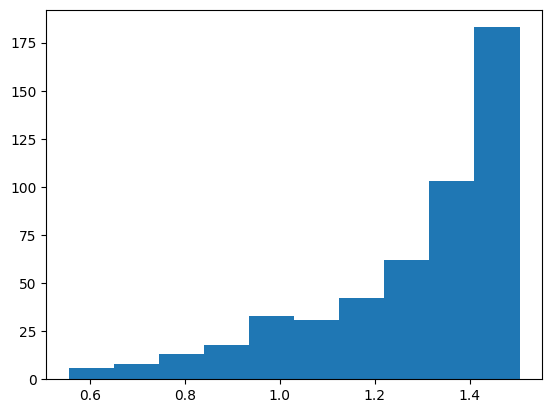

In [18]:
plt.hist(e_val_path_sign)

Final wealth vector: [1.59316891e+01 7.95256222e+27 6.61952355e+49 8.55423754e+67
 2.10451569e+82]
Mean wealth: [5.28074647e+00 1.01127158e+26 4.62547880e+47 4.41686280e+65
 9.05334696e+79]


(array([  4.,  12.,  11.,  26.,  25.,  41.,  32.,  60., 106., 182.]),
 array([0.12 , 0.308, 0.496, 0.684, 0.872, 1.06 , 1.248, 1.436, 1.624,
        1.812, 2.   ]),
 <BarContainer object of 10 artists>)

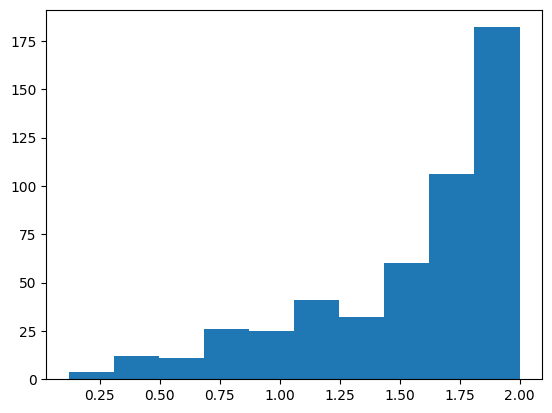

In [19]:
# ----------------------------
# 5. YOUR REAL STRATEGY
# ----------------------------
import numpy as np
from AntisymmetricBet import AntisymmetricBet  # adjust import
from utils import prepare_lambda_parameters, g_family_sign, update_g_func_static

params_sign = prepare_lambda_parameters(lam_start = 0.01, lam_end = 1, lam_num = 5)
strategy_sign = AntisymmetricBet(
    g_family= g_family_sign, 
    update_g_func = update_g_func_static, 
    parameters=params_sign,
    prequential=True,
)


# ----------------------------
# 6. SEQUENTIAL LOOP
# ----------------------------

batch = 5
K = 50

n = len(X_test)

wealth_path = []
e_val_path_sign = []

for t in range(0, n - batch, batch):

    X_batch = X_test[t:t+batch]
    y_batch = y_test[t:t+batch]

    
    X_minus_j = np.delete(X_batch, j, axis=1)

    # conditional samples of X_j | X_-j
    X_tilde = sample_X_tilde(X_minus_j, j, Sigma, K=K)

    # YOUR REAL CALL
    e_val_sign = strategy_sign.e_value(
        model=model,
        x=X_batch,
        x_j_tildes=X_tilde,
        y=y_batch,
        j=j
    )

    strategy_sign.update()
    e_val_path_sign.append(e_val_sign)
    wealth_path.append(strategy_sign.past_martingales.copy())


# ----------------------------
# 7. RESULTS
# ----------------------------

wealth_path = np.array(wealth_path)

print("Final wealth vector:", wealth_path[-1])
print("Mean wealth:", wealth_path.mean(axis=0))
plt.hist(e_val_path_sign)

### Tanh

Final wealth vector: [1.58058287e+01 7.06085630e+27 6.23189559e+49 1.07741696e+68
 6.01677672e+82]
Mean wealth: [5.24764318e+00 9.10744617e+25 4.38594949e+47 5.57204842e+65
 2.58166570e+80]


(array([  4.,  12.,  11.,  26.,  25.,  41.,  32.,  60., 106., 182.]),
 array([0.12 , 0.308, 0.496, 0.684, 0.872, 1.06 , 1.248, 1.436, 1.624,
        1.812, 2.   ]),
 <BarContainer object of 10 artists>)

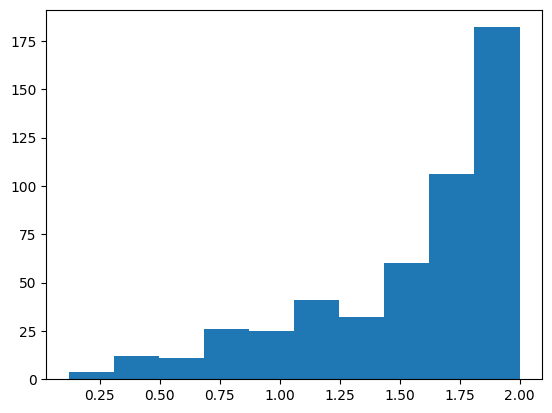

In [20]:
# ----------------------------
# 5. YOUR REAL STRATEGY
# ----------------------------
import numpy as np
from AntisymmetricBet import AntisymmetricBet  # adjust import
from utils import prepare_lambda_parameters, g_family_tanh, update_g_func_static

params_tanh = prepare_lambda_parameters(lam_start = 0.01, lam_end = 1, lam_num = 5)
strategy_tanh = AntisymmetricBet(
    g_family= g_family_tanh, 
    update_g_func = update_g_func_static, 
    parameters=params_tanh,
    prequential=True,
)


# ----------------------------
# 6. SEQUENTIAL LOOP
# ----------------------------

batch = 5
K = 50

n = len(X_test)

wealth_path = []
e_val_path_tanh = []

for t in range(0, n - batch, batch):

    X_batch = X_test[t:t+batch]
    y_batch = y_test[t:t+batch]

    
    X_minus_j = np.delete(X_batch, j, axis=1)

    # conditional samples of X_j | X_-j
    X_tilde = sample_X_tilde(X_minus_j, j, Sigma, K=K)

    # YOUR REAL CALL
    e_val_tanh = strategy_tanh.e_value(
        model=model,
        x=X_batch,
        x_j_tildes=X_tilde,
        y=y_batch,
        j=j
    )

    strategy_tanh.update()
    e_val_path_tanh.append(e_val_tanh)
    wealth_path.append(strategy_tanh.past_martingales.copy())


# ----------------------------
# 7. RESULTS
# ----------------------------

wealth_path = np.array(wealth_path)

print("Final wealth vector:", wealth_path[-1])
print("Mean wealth:", wealth_path.mean(axis=0))
plt.hist(e_val_path_sign)